# Phase 2: Exhaustive Exploratory Data Analysis (EDA)

In this notebook, we perform an in-depth exploratory analysis of the cleaned Dominick's Cereal dataset. The goal is to understand pricing strategies, sales volume (units sold) seasonality, promotional dynamics, and brand-level structures, uncovering empirical evidence of endogeneity that motivates the use of causal machine learning.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os

# Visualization Settings
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Load clean dataset
CLEAN_DATA_PATH = '../data/processed/cereales_clean.csv'
print("Loading clean dataset...")
df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=['START_DATE', 'END_DATE'])
print(f"Dataset successfully loaded. Shape: {df.shape}")

Loading clean dataset...


Dataset successfully loaded. Shape: (4708356, 31)


## 2. Product and Brand Taxonomy

Let's extract the main cereal brands from the `DESCRIP` column. Cereal markets are highly concentrated, and different brands might face different demand curves.

In [2]:
# Extract Brand name from description (usually the first word)
df['brand'] = df['DESCRIP'].str.split().str[0]

# Standardize main brand names (imported from src/feature_engineering.py to avoid duplication)
import sys
sys.path.insert(0, '../src')
from feature_engineering import BRAND_MAPPING
df['brand'] = df['brand'].map(lambda x: BRAND_MAPPING.get(x, 'Other'))

# Analyze brand share
brand_share = df.groupby('brand').agg(
    revenue=('sales', 'sum'),
    units_sold=('units', 'sum'),
    transaction_count=('units', 'count')
).reset_index()

brand_share['revenue_pct'] = (brand_share['revenue'] / brand_share['revenue'].sum()) * 100
brand_share['units_pct'] = (brand_share['units_sold'] / brand_share['units_sold'].sum()) * 100
brand_share = brand_share.sort_values(by='units_pct', ascending=False)
display(brand_share)

,brand,revenue,units_sold,transaction_count,revenue_pct,units_pct
3,Other,1.554902e+08,53513795.75,2785783,58.635162,58.226598
1,Kellogg's,6.108532e+07,21814586.00,890914,23.035206,23.735732
4,Post,2.184392e+07,7293247.00,411039,8.237317,7.935542
5,Quaker,1.658737e+07,5587454.00,384631,6.255080,6.079525
6,Ralston,5.619170e+06,2142837.00,115525,2.118983,2.331550
2,Nabisco,2.443686e+06,889486.00,78963,0.921511,0.967820
0,General Mills,2.112817e+06,664695.00,41501,0.796741,0.723233


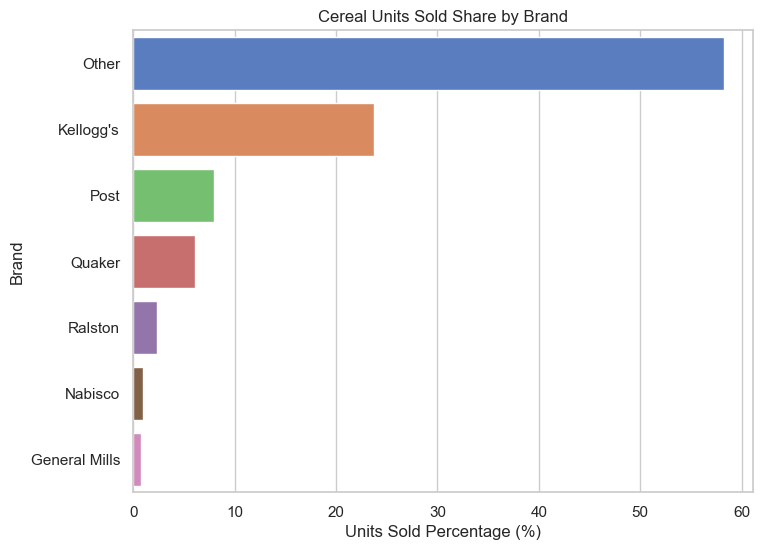

In [3]:
# Plot Brand units sold share
plt.figure(figsize=(8, 6))
sns.barplot(data=brand_share, x='units_pct', y='brand', hue='brand', legend=False)
plt.title("Cereal Units Sold Share by Brand")
plt.xlabel("Units Sold Percentage (%)")
plt.ylabel("Brand")
plt.show()

## 3. Price Distribution and Pricing Zones

Dominick's segment stores into price zones (e.g. High, Medium, Low) based on localized demographics and competition. Let's see how pricing varies across zones.

In [4]:
# Filter out price zones with very few stores if any
df = df[df['PRICE_ZONE'].notna()]

# Check count of transactions and average price by Price Zone
zone_summary = df.groupby('PRICE_ZONE').agg(
    store_count=('STORE', 'nunique'),
    avg_price=('PRICE', 'mean'),
    median_price=('PRICE', 'median'),
    total_units=('units', 'sum')
).reset_index()
display(zone_summary)

,PRICE_ZONE,store_count,avg_price,median_price,total_units
0,CubFighter,9,3.014631,2.99,1.158670e+07
1,High,25,3.190747,3.22,2.692112e+07
2,Low,9,3.083257,3.09,1.155940e+07
3,Medium,42,3.096154,3.10,4.098052e+07


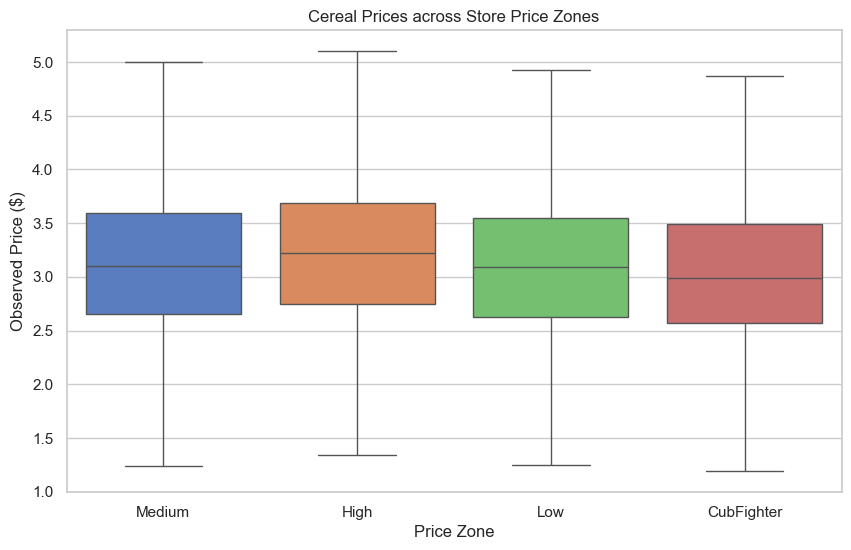

In [5]:
# Boxplot of prices across different pricing zones
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='PRICE_ZONE', y='PRICE', showfliers=False, hue='PRICE_ZONE', legend=False)
plt.title("Cereal Prices across Store Price Zones")
plt.xlabel("Price Zone")
plt.ylabel("Observed Price ($)")
plt.show()

## 4. Promotional Dynamics

Promotions are frequent in retail and cause price drops and sales spikes. Let's inspect the frequency and depth of promotions.

In [6]:
# Overall promotion frequency
promo_freq = df['promotion'].value_counts(normalize=True) * 100
print(f"Percentage of records under promotion: {promo_freq[1]:.2f}%")

# Promotion frequency by Price Zone
promo_zone = df.groupby('PRICE_ZONE')['promotion'].mean().reset_index()
promo_zone['promotion_pct'] = promo_zone['promotion'] * 100
display(promo_zone)

Percentage of records under promotion: 7.55%


,PRICE_ZONE,promotion,promotion_pct
0,CubFighter,0.070276,7.027564
1,High,0.079472,7.947203
2,Low,0.074284,7.428415
3,Medium,0.074627,7.462670


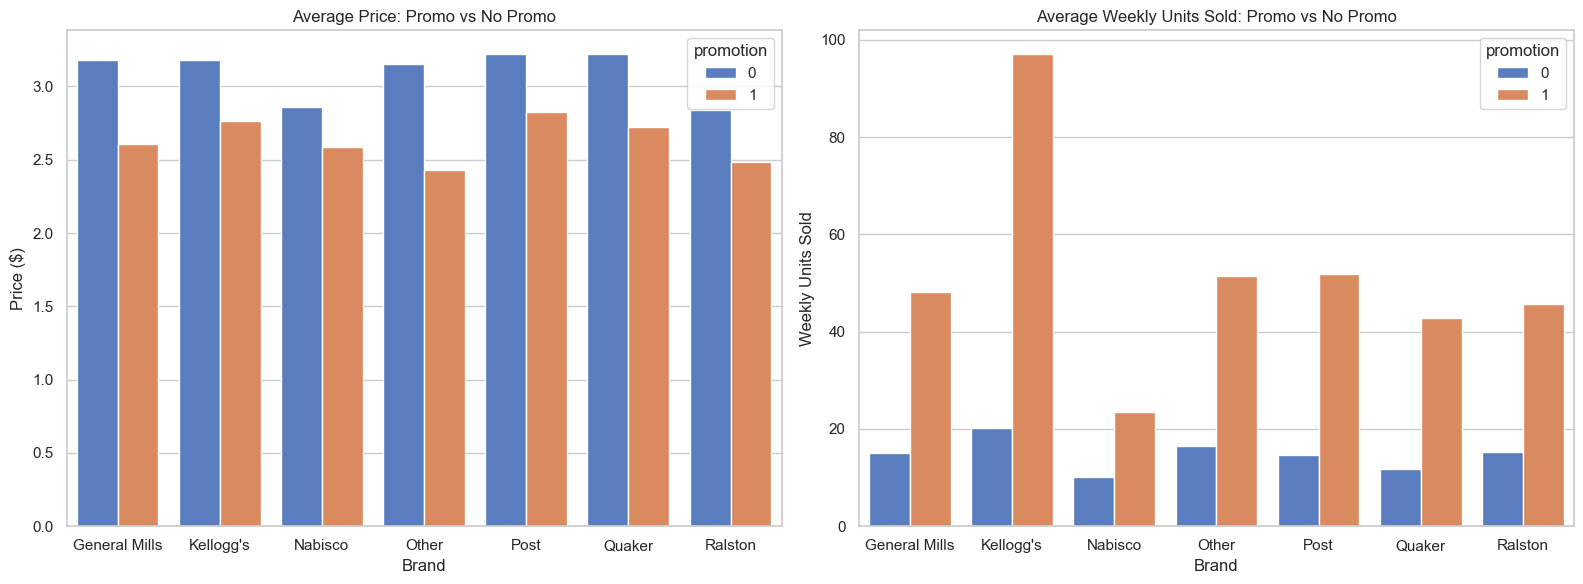

In [7]:
# Compare average price and units sold during promotions vs normal periods
promo_impact = df.groupby(['brand', 'promotion']).agg(
    avg_price=('PRICE', 'mean'),
    avg_units=('units', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=promo_impact, x='brand', y='avg_price', hue='promotion', ax=axes[0])
axes[0].set_title("Average Price: Promo vs No Promo")
axes[0].set_xlabel("Brand")
axes[0].set_ylabel("Price ($)")

sns.barplot(data=promo_impact, x='brand', y='avg_units', hue='promotion', ax=axes[1])
axes[1].set_title("Average Weekly Units Sold: Promo vs No Promo")
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Weekly Units Sold")
plt.tight_layout()
plt.show()

## 5. Temporal Trends and Seasonality

Demand for cereal exhibits seasonality (e.g. spikes around 'Back to School' in late summer/early autumn). If retailers change prices in response to these seasonal shifts, OLS estimates of elasticity will be biased.

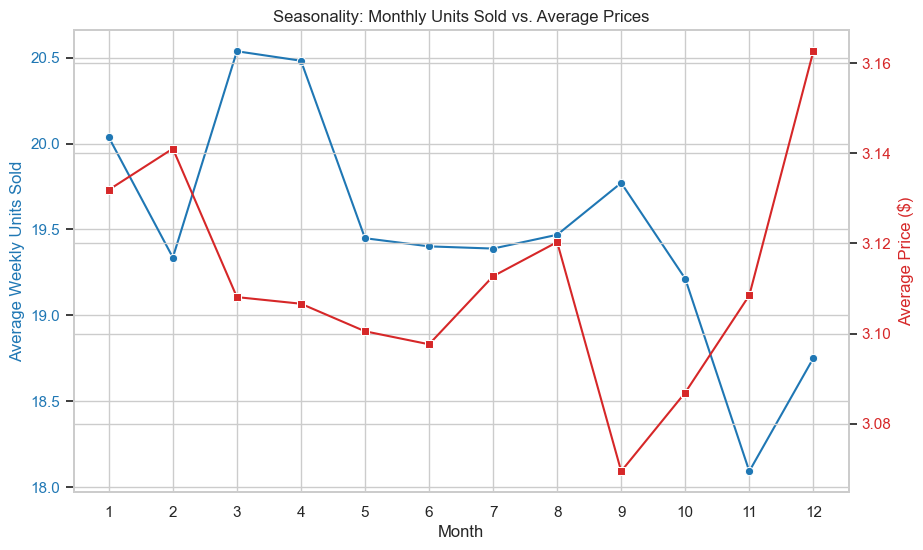

In [8]:
# Monthly seasonality of units sold
monthly_sales = df.groupby('month').agg(
    avg_units=('units', 'mean'),
    avg_price=('PRICE', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Weekly Units Sold', color=color)
sns.lineplot(data=monthly_sales, x='month', y='avg_units', marker='o', ax=ax1, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Price ($)', color=color)
sns.lineplot(data=monthly_sales, x='month', y='avg_price', marker='s', ax=ax2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Seasonality: Monthly Units Sold vs. Average Prices")
plt.show()

## 6. The Endogeneity of Price (The Log-Log Relationship)

Let's look at the correlation between units sold and prices using a naive log-log regression. A basic econometric demand model is:
$$\log(\text{Units}) = \alpha + \beta \log(\text{Price}) + \epsilon$$
Where $\beta$ is the price elasticity of demand.

In [9]:
# Naive OLS Regression (entire dataset)
model_naive = smf.ols("log_units ~ log_price", data=df).fit()
print(model_naive.summary())

                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                 5.678e+04
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:35:48   Log-Likelihood:            -6.2050e+06
No. Observations:             4674202   AIC:                         1.241e+07
Df Residuals:                 4674200   BIC:                         1.241e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8630      0.002   1741.722      0.0

/Users/percy/Proyectos/Pricing_Elasticity/venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/percy/Proyectos/Pricing_Elasticity/venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/percy/Proyectos/Pricing_Elasticity/venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


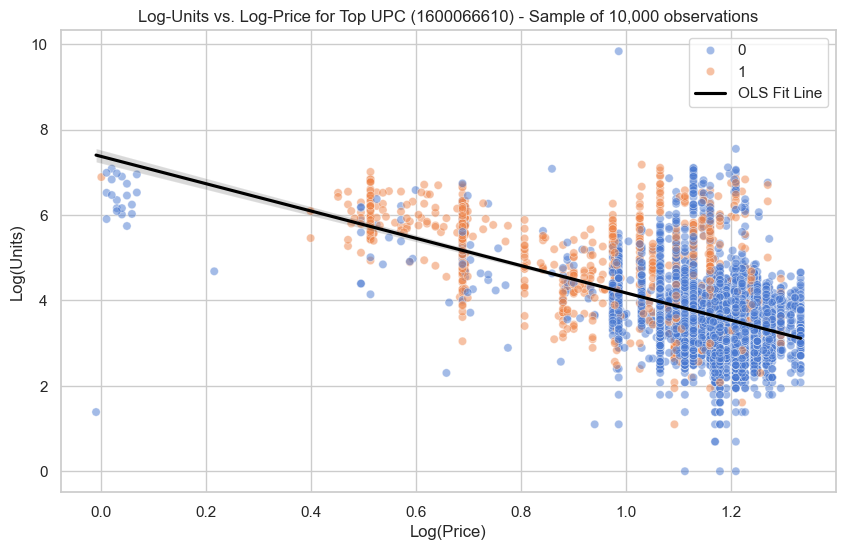

In [10]:
# Let's visualize the log-log relationship for a single top-selling UPC to see the price variations
top_upc = df.groupby('UPC')['units'].sum().idxmax()
df_top_upc = df[df['UPC'] == top_upc].sample(n=10000, random_state=42) # Sample to avoid overplotting

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_top_upc, x='log_price', y='log_units', hue='promotion', alpha=0.5)
sns.regplot(data=df_top_upc, x='log_price', y='log_units', scatter=False, color='black', label='OLS Fit Line')
plt.title(f"Log-Units vs. Log-Price for Top UPC ({top_upc}) - Sample of 10,000 observations")
plt.xlabel("Log(Price)")
plt.ylabel("Log(Units)")
plt.legend()
plt.show()

## 7. Key Findings and Implications for Causal Machine Learning

1. **Strong Promotional Spikes**: During promotions, sales units are substantially higher while prices are systematically dropped. If we estimate elasticity without isolating the causal mechanism of promotion, we will mix up the pure price effect with the promotional advertising effect.
2. **Zone Heterogeneity**: Pricing levels differ significantly between Low and High price zones. This confirms that the demand response (elasticity) is likely heterogeneous across stores, justifying a CATE model like **Causal Forests**.
3. **Price Endogeneity**: The naive regression on quantities reveals a biased elasticity. Since price adjustments are strongly correlated with promotions, time factors (seasonality), and stores, OLS estimates suffer from omitted variable bias (confounding). Double Machine Learning (DML) is required to orthogonalize the price and units residuals from these confounders.